In [2]:
import geopandas as gpd
from shapely.geometry import MultiPolygon
import pandas as pd
import os

from shapely import wkt


### Construct 5km*5km grid

os.chdir('/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding_Anora')

# Load and project JX polygon ONCE
jx_poly = gpd.read_file('jiangxi/jiangxi_shape.shp').geometry.iloc[0]
jx_poly_proj = gpd.GeoSeries([jx_poly], crs="EPSG:4326").to_crs("EPSG:4527").iloc[0]

jx_wkt_proj = jx_poly_proj.wkt               # safe for spawn
jx_bounds = jx_poly_proj.bounds              # simple tuple → safe

minx, miny, maxx, maxy = jx_bounds
minx, miny, maxx, maxy

(39161358.71620327, 2711879.6380870277, 39645343.296451576, 3329014.1446083155)

<Axes: >

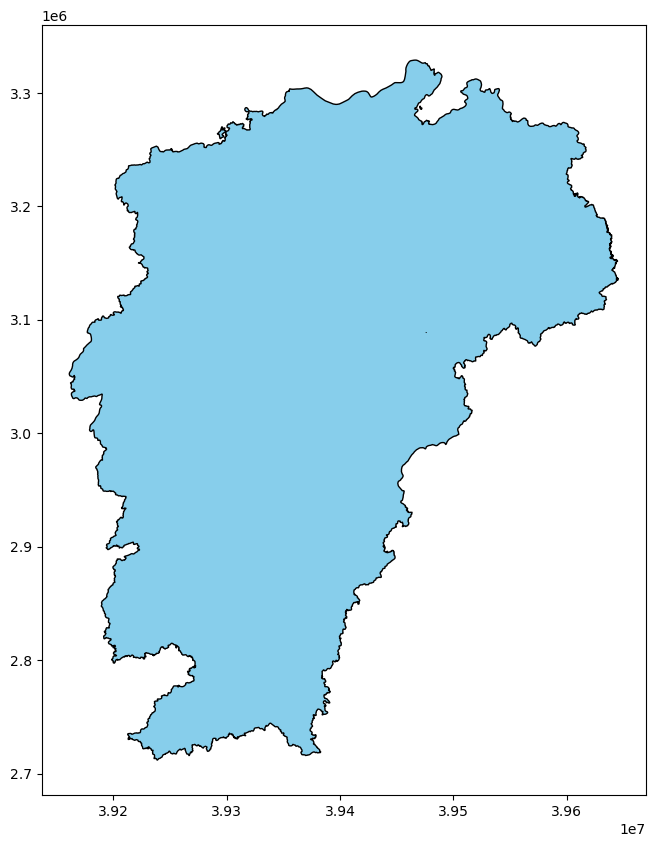

In [7]:
import matplotlib.pyplot as plt
import geopandas as gpd

# 1. Create the figure and axis
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot the projected geometry
# We wrap it in a GeoSeries if it isn't one already
gpd.GeoSeries([jx_poly_proj]).plot(ax=ax, color='skyblue', edgecolor='black')

In [ ]:
import numpy as np

# Build 5km grid
grid_size = 5000

x_bins = np.arange(minx, maxx + grid_size, grid_size)
y_bins = np.arange(miny, maxy + grid_size, grid_size)


In [ ]:
# Read operation data
import numpy as np
operation_data = pd.read_csv('operation/cleaned_data.csv')
xs = np.array(operation_data['lon'])
xs

numpy.float64

In [13]:
operation_data['lon']

0       113.65000
1       113.86000
2       114.95000
3       113.65000
4       117.08000
          ...    
9587    114.99111
9588    115.34083
9589    115.99333
9590    115.91861
9591    115.35111
Name: lon, Length: 9592, dtype: float64

In [17]:
operation_data.columns

Index(['Unnamed: 0', 'date', 'start_time', 'end_time', 'city_o', 'county_o',
       'tool', 'num', 'weather_before', 'weather_after', 'area', 'effect',
       'field', 'lon', 'lat', 'geometry', 'index_right', 'prov', 'city',
       'county', 'town', 'type', 'num_gaopao', 'num_rocket', 'num_cigar',
       'num_other', 'location_o'],
      dtype='object')

In [24]:
operation_data['date'] = pd.to_datetime(operation_data['date'])
type(operation_data['date'][0])
operation_data['date'].dt.dayofyear

0       362
1       362
2       360
3       360
4       359
       ... 
9587    364
9588    364
9589    364
9590    364
9591    364
Name: date, Length: 9592, dtype: int32

In [25]:
operation_data['date'] = pd.to_datetime(operation_data['date'])
type(operation_data['date'][0])
operation_data['date']

0      2021-12-28
1      2021-12-28
2      2021-12-26
3      2021-12-26
4      2021-12-25
          ...    
9587   2020-12-29
9588   2020-12-29
9589   2020-12-29
9590   2020-12-29
9591   2020-12-29
Name: date, Length: 9592, dtype: datetime64[ns]